In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import precision_score, recall_score, f1_score

RANDOM_STATE = 36

In [48]:
data = pd.read_csv('ai4i2020.csv')
data.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Removing Irrelevant Columns

In [49]:
data = data.drop(['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis='columns')


## Coding Type

In [50]:
data_cleaned = pd.get_dummies(data, columns=['Type'],dtype='int', drop_first=True)
data_cleaned

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0
...,...,...,...,...,...,...,...,...
9995,298.8,308.4,1604,29.5,14,0,0,1
9996,298.9,308.4,1632,31.8,17,0,0,0
9997,299.0,308.6,1645,33.4,22,0,0,1
9998,299.0,308.7,1408,48.5,25,0,0,0


# Splitting data

In [51]:
x_train_scaled = data_cleaned[data_cleaned['Machine failure'] == 0].sample(n=7000, random_state=RANDOM_STATE)
_x = data_cleaned.sample(n=3000, random_state=RANDOM_STATE)

print(x_train_scaled.shape, _x.shape)

(7000, 8) (3000, 8)


In [52]:
x_cv, x_test = train_test_split(_x, test_size=0.5, random_state=RANDOM_STATE)
print(x_cv.shape, x_test.shape)
print(
    (x_cv['Machine failure'] == 1).sum(),
    (x_test['Machine failure'] == 1).sum()
      )

(1500, 8) (1500, 8)
59 53


0.11427392052155025


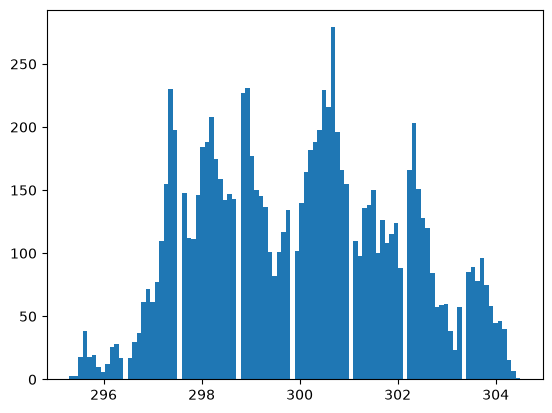

In [53]:
print(data['Air temperature [K]'].skew())
plt.hist(data['Air temperature [K]'], bins=100)
plt.show()
# Data is a Gaussian distribution

# Scaling Data

In [54]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_scaled)
x_cv_scaled = scaler.transform(x_cv)
x_test_scaled = scaler.transform(x_test)
x_cv_scaled

array([[-1.4461229 , -1.21183722, -0.67131381, ...,  0.        ,
         0.81601066, -0.65376311],
       [ 1.87955522,  1.89197749,  1.7433707 , ...,  0.        ,
         0.81601066, -0.65376311],
       [-0.74067603, -0.87446606, -1.14828852, ...,  0.        ,
        -1.22547419,  1.52960605],
       ...,
       [-2.10118071, -2.29142495, -0.18837691, ...,  0.        ,
         0.81601066, -0.65376311],
       [ 0.97255209,  0.6774413 , -0.92768772, ...,  0.        ,
        -1.22547419,  1.52960605],
       [-0.33756353, -1.07688876, -0.79651967, ...,  0.        ,
         0.81601066, -0.65376311]], shape=(1500, 8))

# Choosing Contaminatinos

In [55]:
contaminations = [0.5,0.1, 0.05, 0.02, 0.01]
anamolies_temp = []

for i in contaminations:
    model = IsolationForest(contamination=i, random_state=RANDOM_STATE, n_jobs=10)
    model.fit(x_train_scaled)

    was_anamoly_temp = model.predict(x_train_scaled)
    x_train_scaled = scaler.fit_transform(x_train_scaled)
    
    sus = (was_anamoly_temp == -1).sum() 

    anamolies_temp.append(sus)
sus


np.int64(70)

# Fitting Model

In [56]:
model = IsolationForest(contamination=0.05, random_state=RANDOM_STATE, n_jobs=10)
model.fit(x_train_scaled)
anom_train = model.predict(x_train_scaled)
anom_train_sum= (anom_train == -1).sum() 
anom_train_sum

np.int64(350)

In [57]:

anom_cv = model.predict(x_cv_scaled)

anom_cv_sum = (anom_cv == -1).sum() 
anom_cv_sum

np.int64(89)

# Calculating Prescision & Recall & F1 Score

In [58]:
y_cv = x_cv['Machine failure']

anom_cv = (anom_cv == -1).astype(int)

precision = precision_score(y_cv, anom_cv)
recall = precision_score(y_cv, anom_cv)
f1_score = f1_score(y_cv, anom_cv)

report = classification_report(y_cv, anom_cv)

confusion = confusion_matrix(y_cv, anom_cv)

In [59]:
print(
    f"Precision: {precision:.3f}\n"
    f"Recall:    {recall:.3f}\n"
    f"F1 Score:  {f1_score:.3f}\n"
)

print(f'Classification Error: \n{report}')
print(f'Confusion Matrix: \n{confusion}')

Precision: 0.112
Recall:    0.112
F1 Score:  0.135

Classification Error: 
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1441
           1       0.11      0.17      0.14        59

    accuracy                           0.91      1500
   macro avg       0.54      0.56      0.55      1500
weighted avg       0.93      0.91      0.92      1500

Confusion Matrix: 
[[1362   79]
 [  49   10]]


# Using XGBoost